# AirNow and UFS-CHEM

Our first example will demonstrate the basics available in MELODIES MONET to 
compare the meteorological capabilities of UFS-CHEM results against AirNow surface observations. We will analyze variables including temperature, dewpoint, windspeed, and wind direction.

First, we import the {mod}`melodies_monet.driver` module.

In [1]:
from melodies_monet import driver

## Analysis driver class

Now, lets create an instance of the analysis driver class, {class}`melodies_monet.driver.analysis`.
It consists of these main parts:
* model instances
* observation instances
* a paired instance of both

In [2]:
an = driver.analysis()

Initially, most of our {class}`~melodies_monet.driver.analysis` object's attributes
are set to ``None``, though some have meaningful defaults:

In [3]:
an

analysis(
    control='control.yaml',
    control_dict=None,
    models={},
    obs={},
    paired={},
    start_time=None,
    end_time=None,
    time_intervals=None,
    download_maps=True,
    output_dir=None,
    output_dir_save=None,
    output_dir_read=None,
    debug=False,
    save=None,
    read=None,
    regrid=False,
)

## Control file

We set the YAML control file and begin by reading the file.

```{note}
Check out the {doc}`/appendix/yaml` for info on how to create
and modify these files.
```

In [4]:
an.control = "control_ufschem-example.yaml"
an.read_control()
an.control_dict

{'analysis': {'start_time': '2017-07-01-00:00:00',
  'end_time': '2017-07-03-00:00:00',
  'output_dir': './output/airnow_ufschem',
  'debug': True},
 'model': {'ufschem_v1': {'files': 'example:ufschem:2017-07',
   'mod_type': 'ufschem',
   'mod_kwargs': {'surf_only': True},
   'radius_of_influence': 100000,
   'extra_calc': {'dewpoint': {'specific_hum': 'spfh'},
    'rel_hum': {'specific_hum': 'spfh'},
    'windspeed': {'u_comp': 'ugrd', 'v_comp': 'vgrd'},
    'winddir': {'u_comp': 'ugrd', 'v_comp': 'vgrd'}},
   'mapping': {'airnow': {'o3': 'OZONE',
     'temperature_k': 'TEMP',
     'windspeed': 'WS',
     'winddir': 'WD',
     'rel_hum': 'RHUM'}},
   'projection': None,
   'plot_kwargs': {'color': 'magenta', 'marker': 's', 'linestyle': '-'}}},
 'obs': {'airnow': {'use_airnow': True,
   'filename': 'example:airnow:2017-07',
   'obs_type': 'pt_sfc',
   'variables': {'OZONE': {'unit_scale': 1,
     'unit_scale_method': '*',
     'nan_value': -1.0,
     'ylabel_plot': 'Ozone (ppbv)',
   

````{admonition} Note: This is the complete file that was loaded.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
```
````

Now, some of our {class}`~melodies_monet.driver.analysis` object's attributes are populated:

In [5]:
an

analysis(
    control='control_ufschem-example.yaml',
    control_dict=...,
    models={},
    obs={},
    paired={},
    start_time=Timestamp('2017-07-01 00:00:00'),
    end_time=Timestamp('2017-07-03 00:00:00'),
    time_intervals=None,
    download_maps=True,
    output_dir='./output/airnow_ufschem',
    output_dir_save='./output/airnow_ufschem',
    output_dir_read='./output/airnow_ufschem',
    debug=True,
    save=None,
    read=None,
    regrid=False,
)

## Load the model data

The driver will automatically loop through the "models" found in the `model` section
of the YAML file and create an instance of {class}`melodies_monet.driver.model` for each
that includes the
* label
* mapping information
* file names (can be expressed using a glob expression)
* xarray object

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 24-56
```
````

In [6]:
an.open_models()

example:ufschem:2017-07
extra_calc keys (MOD): ['dewpoint', 'rel_hum', 'windspeed', 'winddir']
**** Reading UFS-CHEM model output...
Performing extra calculations...
Calculating modeled Dewpoint...
Calculating modeled relative humidity...
Calculating modeled windpseed...
Calculating modeled wind direction...
No extra calculations performed.


Applying {meth}`~melodies_monet.driver.analysis.open_models`
populates the {attr}`~melodies_monet.driver.analysis.models` attribute.

We can access the underlying dataset with the
{attr}`~melodies_monet.driver.model.obj` attribute.

In [7]:
an.models['ufschem_v1'].obj

<xarray.Dataset> Size: 383MB
Dimensions:        (time: 72, z: 1, y: 192, x: 384)
Coordinates:
    latitude       (y, x) float64 590kB dask.array<chunksize=(192, 384), meta=np.ndarray>
    longitude      (y, x) float64 590kB dask.array<chunksize=(192, 384), meta=np.ndarray>
  * time           (time) datetime64[ns] 576B 2017-07-01T01:00:00 ... 2017-07-04
Dimensions without coordinates: z, y, x
Data variables: (12/14)
    spfh           (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    ugrd           (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    vgrd           (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    o3             (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    temperature_k  (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    surfpres_pa    (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    ...             ...
    dz_m           (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    pres_pa_mid    (time, z, y, x) float32 21MB 37.92 37.92 ... 37.92 37.92
    dewpoint       (time, z, y, x) float64 42MB 271.7 271.7 ... 217.3 217.2
    rel_hum        (time, z, y, x) float64 42MB 94.35 94.35 ... 66.12 66.08
    windspeed      (time, z, y, x) float64 42MB 6.511 6.511 6.511 ... 6.09 6.085
    winddir        (time, z, y, x) float64 42MB 246.6 247.4 ... 350.2 349.4
Attributes:
    ak:           [2.0000000e+01 6.4247000e+01 1.3779000e+02 2.2195800e+02 3....
    bk:           [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0....
    grid:         gaussian
    grid_id:      1
    hydrostatic:  non-hydrostatic
    im:           384
    jm:           192
    ncnsto:       139
    source:       FV3GFS
    history:      Wed Jun 25 09:54:47 2025: ncrcat 20170701_dynf001.nc 201707...
    NCO:          netCDF Operators version 5.0.7 (Homepage = http://nco.sf.ne...

## Load the observational data

As with the model data, the driver will loop through the "observations" found in
the `obs` section of the YAML file and create an instance of
{class}`melodies_monet.driver.observation` for each.

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 58-99
```
````

In [8]:
an.open_obs()

extra_calc keys (OBS): None


In [9]:
an.obs

{'airnow': observation(
     obs='airnow',
     label='airnow',
     file='example:airnow:2017-07',
     obj=...,
     extra_calc=None,
     type='pt_src',
     sat_type=None,
     data_proc=None,
     variable_dict={'OZONE': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -1.0, 'ylabel_plot': 'Ozone (ppbv)', 'xlabel_plot': 'Ozone (ppbv)', 'vmin_plot': 15.0, 'vmax_plot': 100, 'vdiff_plot': 20.0, 'nlevels_plot': 21}, 'TEMP': {'unit_scale': 273.15, 'unit_scale_method': '+', 'nan_value': -1.0, 'ylabel_plot': 'Temperature (K)', 'xlabel_plot': 'Temperature (K)', 'vmin_plot': 275, 'vmax_plot': 320, 'vdiff_plot': 20.0, 'nlevels_plot': 21}, 'WS': {'unit_scale': 1, 'nan_value': -1.0, 'ylabel_plot': 'Windspeed (m/s)', 'xlabel_plot': 'Windspeed (m/s)', 'vmin_plot': 0, 'vmax_plot': 10, 'vdiff_plot': 4, 'nlevels_plot': 18}, 'WD': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -1.0, 'ylabel_plot': 'Wind Direction (deg)', 'xlabel_plot': 'Wind Direction (deg)', 'vmin_plot': 0, 'vmax

In [10]:
an.obs['airnow'].obj

<xarray.Dataset> Size: 18MB
Dimensions:     (time: 49, y: 1, x: 1934)
Coordinates:
  * time        (time) datetime64[ns] 392B 2017-07-01 ... 2017-07-03
    siteid      (x) <U9 70kB ...
    latitude    (x) float64 15kB ...
    longitude   (x) float64 15kB ...
  * x           (x) int64 15kB 0 1 2 3 4 5 6 ... 1928 1929 1930 1931 1932 1933
Dimensions without coordinates: y
Data variables: (12/30)
    BARPR       (time, y, x) float64 758kB ...
    BC          (time, y, x) float64 758kB ...
    CO          (time, y, x) float64 758kB ...
    NO          (time, y, x) float64 758kB ...
    NO2         (time, y, x) float64 758kB ...
    NO2Y        (time, y, x) float64 758kB ...
    ...          ...
    utcoffset   (y, x) int64 15kB ...
    cmsa_name   (y, x) float64 15kB ...
    msa_code    (y, x) float64 15kB ...
    msa_name    (y, x) <U52 402kB ...
    state_name  (y, x) <U2 15kB ...
    epa_region  (y, x) <U5 39kB ...

## Pair model and observational data

Now, we create a {class}`melodies_monet.driver.pair` for each model--obs pair
using the {meth}`~melodies_monet.driver.analysis.pair_data` routine.

In [11]:
%%time

an.pair_data()

1, in pair data
After pairing:              time  BARPR  BC  CO   NO  NO2  NO2Y  NOX  NOY  OC  ...  \
0     2017-07-01    NaN NaN NaN  NaN  NaN   NaN  NaN  NaN NaN  ...   
1     2017-07-01    NaN NaN NaN  0.0  1.0   NaN  NaN  NaN NaN  ...   
2     2017-07-01    NaN NaN NaN  0.0  1.0   NaN  NaN  NaN NaN  ...   
3     2017-07-01    NaN NaN NaN  0.0  0.0   NaN  NaN  NaN NaN  ...   
4     2017-07-01    NaN NaN NaN  1.0  NaN   NaN  NaN  NaN NaN  ...   
...          ...    ...  ..  ..  ...  ...   ...  ...  ...  ..  ...   
94761 2017-07-03    NaN NaN NaN  NaN  NaN   NaN  NaN  NaN NaN  ...   
94762 2017-07-03    NaN NaN NaN  NaN  NaN   NaN  NaN  NaN NaN  ...   
94763 2017-07-03    NaN NaN NaN  NaN  NaN   NaN  NaN  NaN NaN  ...   
94764 2017-07-03    NaN NaN NaN  NaN  NaN   NaN  NaN  NaN NaN  ...   
94765 2017-07-03    NaN NaN NaN  NaN  NaN   NaN  NaN  NaN NaN  ...   

       state_name  epa_region         o3  temperature_k  windspeed  \
0              CC          CA        NaN            NaN  

In [12]:
an.paired

{'airnow_ufschem_v1': pair(
     type='pt_sfc',
     radius_of_influence=1000000.0,
     obs='airnow',
     model='ufschem_v1',
     model_vars=['o3', 'temperature_k', 'windspeed', 'winddir', 'rel_hum'],
     obs_vars=['OZONE', 'TEMP', 'WS', 'WD', 'RHUM'],
     filename='airnow_ufschem_v1.nc',
 )}

In [13]:
an.paired['airnow_ufschem_v1']

pair(
    type='pt_sfc',
    radius_of_influence=1000000.0,
    obs='airnow',
    model='ufschem_v1',
    model_vars=['o3', 'temperature_k', 'windspeed', 'winddir', 'rel_hum'],
    obs_vars=['OZONE', 'TEMP', 'WS', 'WD', 'RHUM'],
    filename='airnow_ufschem_v1.nc',
)

## MELODIES-MONET now contains several meteorological capabilities 

In addition to previous capabilites and plots, users can now:

* Specify wind barbs
    * Note: users may experience longer wait times if they wish to plot wind barbs
* Create rose plots for pollution and wind speed
    * Rose plots can be aggregated across scales (e.g. EPA region and CONUS)
* Create boxplots on given intervals for any of the supported meteorological variables 
* Mark statistical significance on boxplots


## Plot

The {meth}`~melodies_monet.driver.analysis.plotting` routine produces plots.

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 101-240
```
````

U-comp and V-comp need to be specified in the yaml file. Plotting wind barbs failed!
U-comp and V-comp need to be specified in the yaml file. Plotting wind barbs failed!
U-comp and V-comp need to be specified in the yaml file. Plotting wind barbs failed!
U-comp and V-comp need to be specified in the yaml file. Plotting wind barbs failed!
U-comp and V-comp need to be specified in the yaml file. Plotting wind barbs failed!
U-comp and V-comp need to be specified in the yaml file. Plotting wind barbs failed!
U-comp and V-comp need to be specified in the yaml file. Plotting wind barbs failed!
U-comp and V-comp need to be specified in the yaml file. Plotting wind barbs failed!
U-comp and V-comp need to be specified in the yaml file. Plotting wind barbs failed!
U-comp and V-comp need to be specified in the yaml file. Plotting wind barbs failed!
[0.6481618976700385]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-

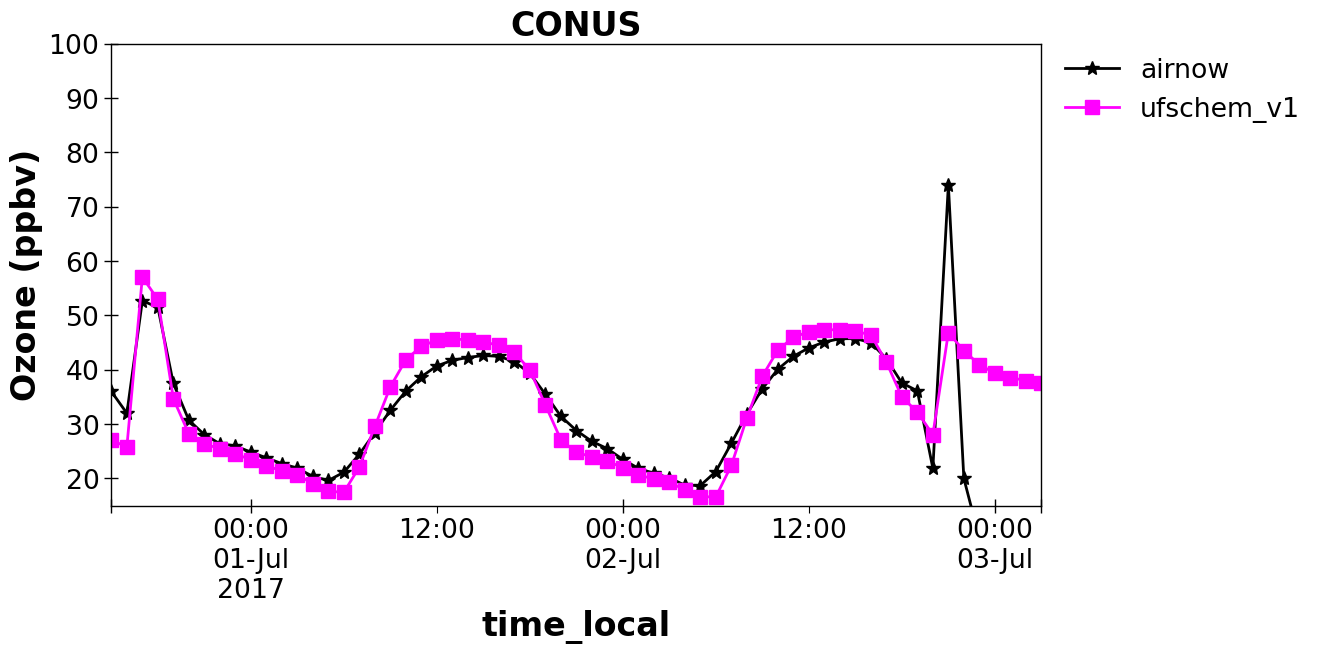

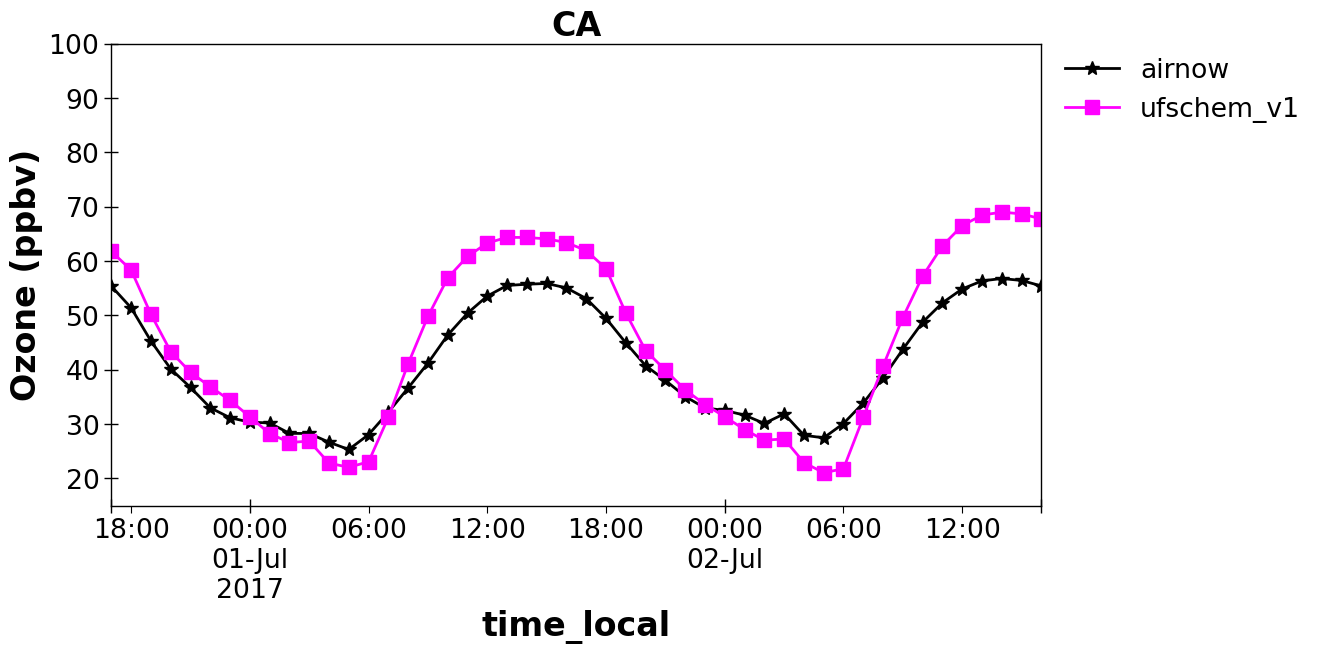

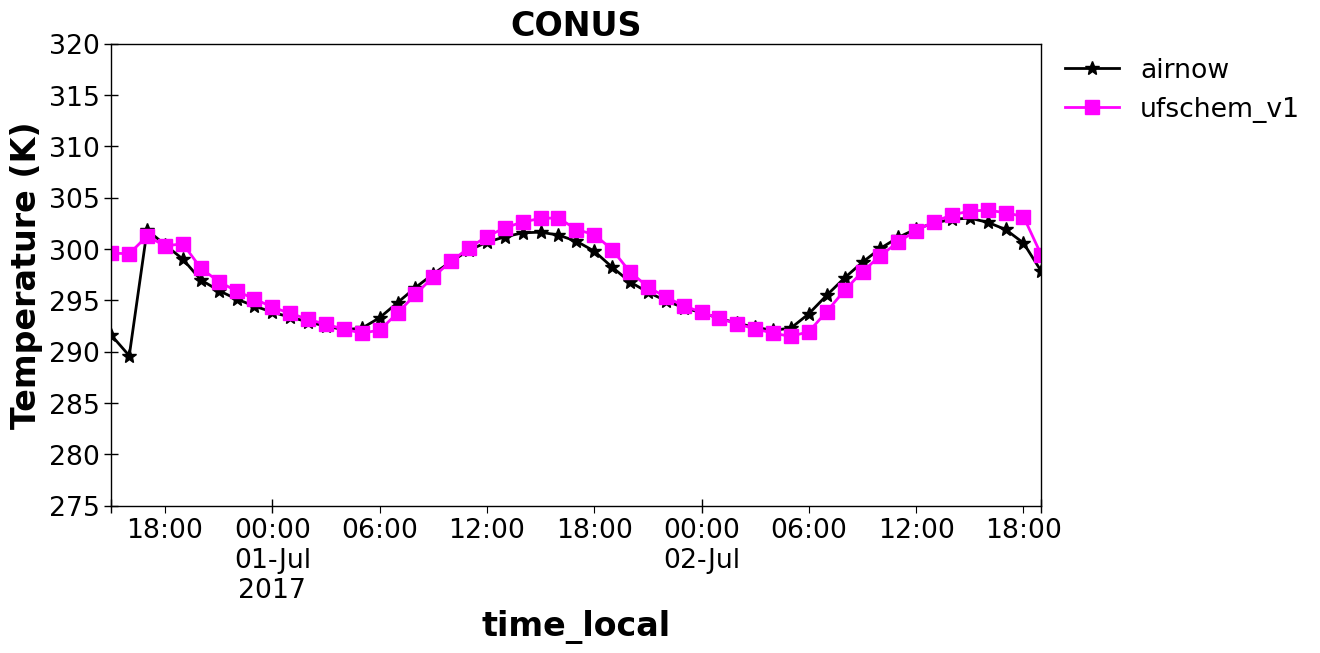

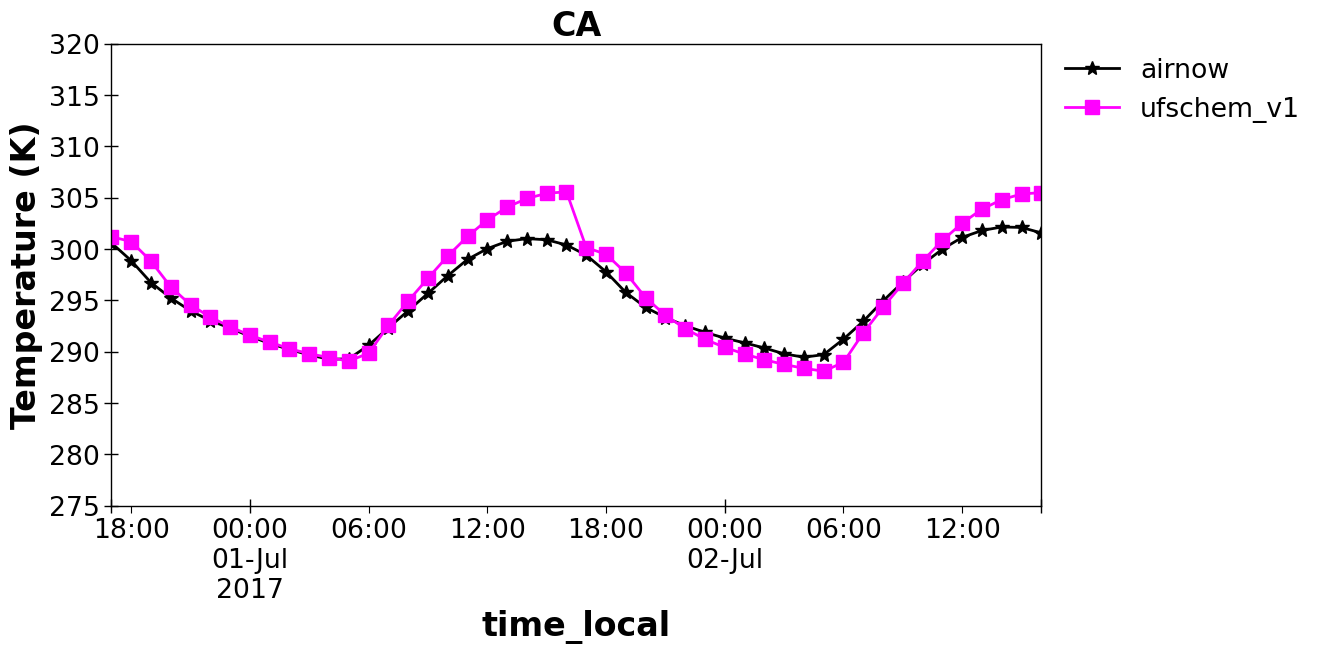

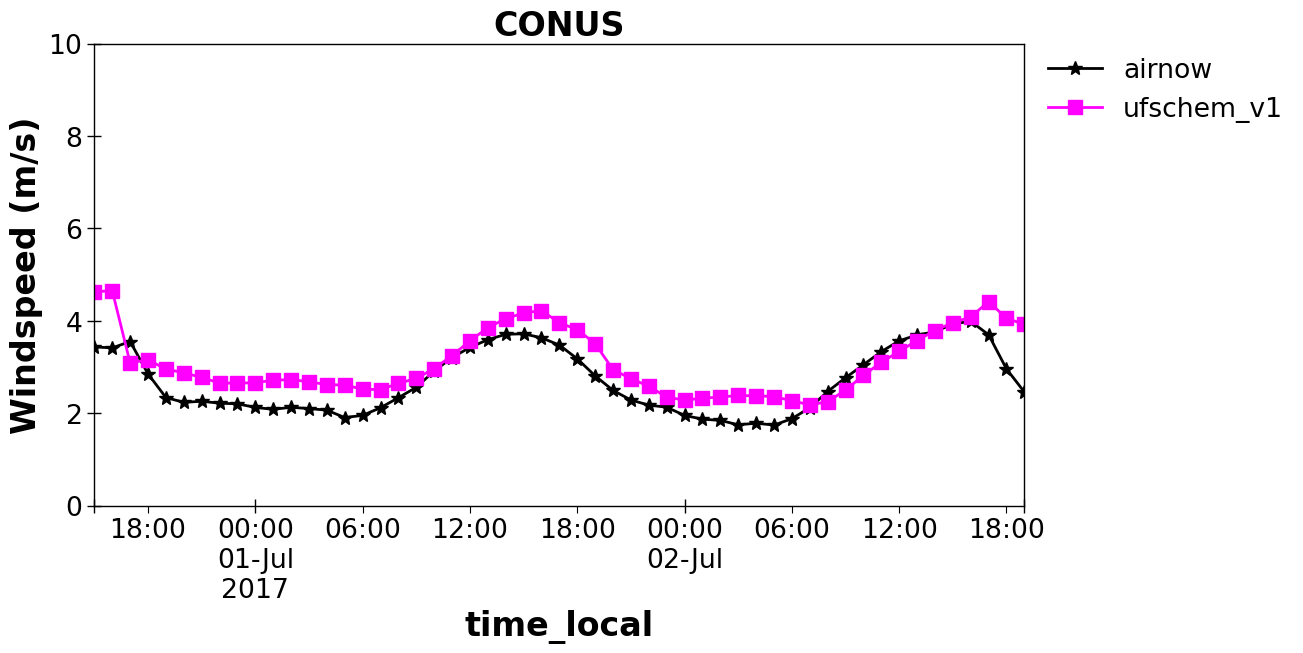

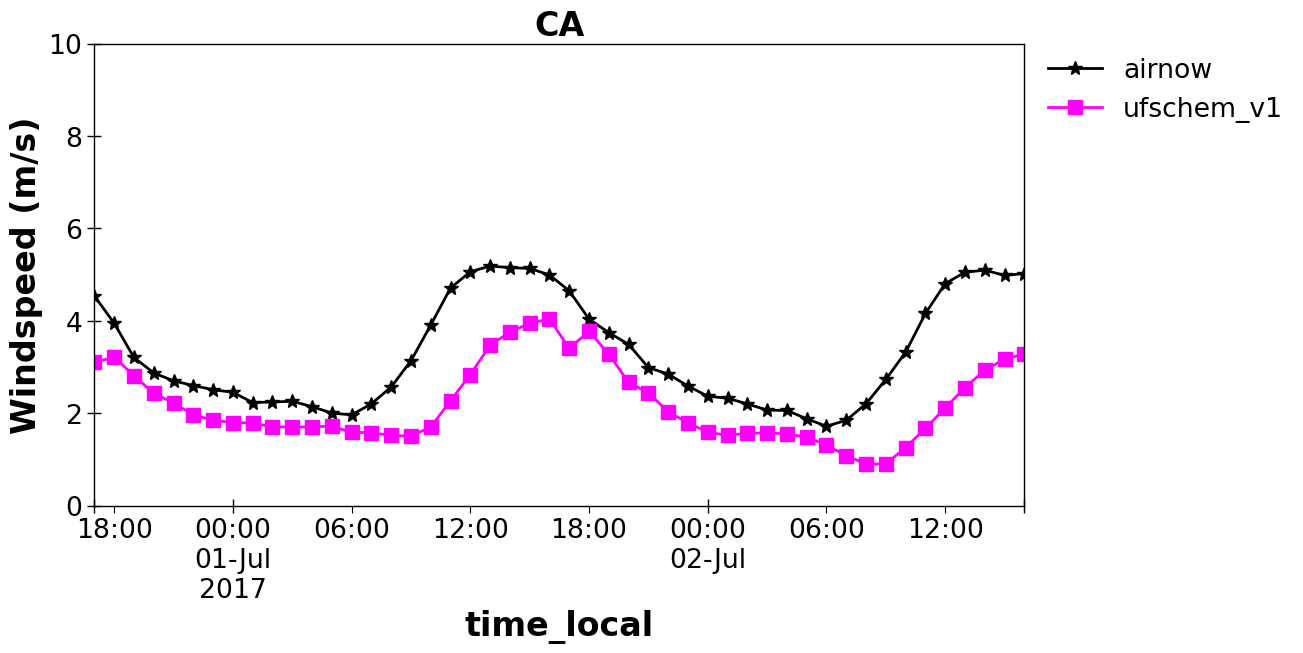

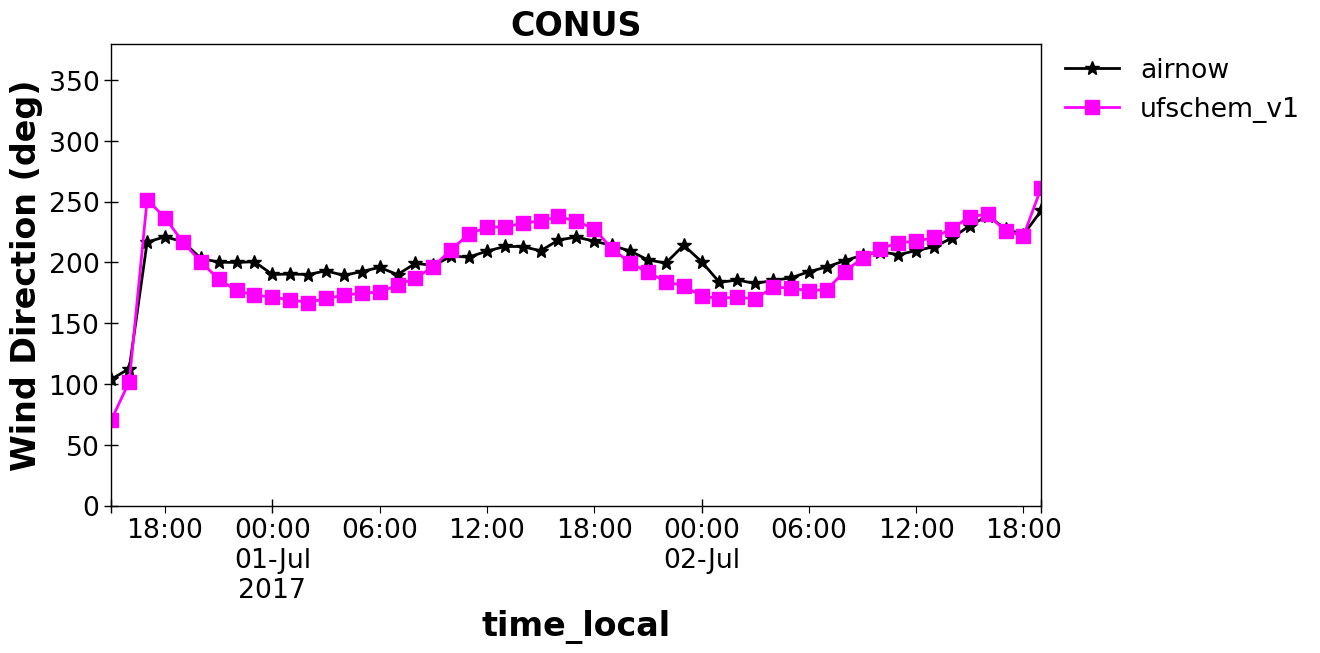

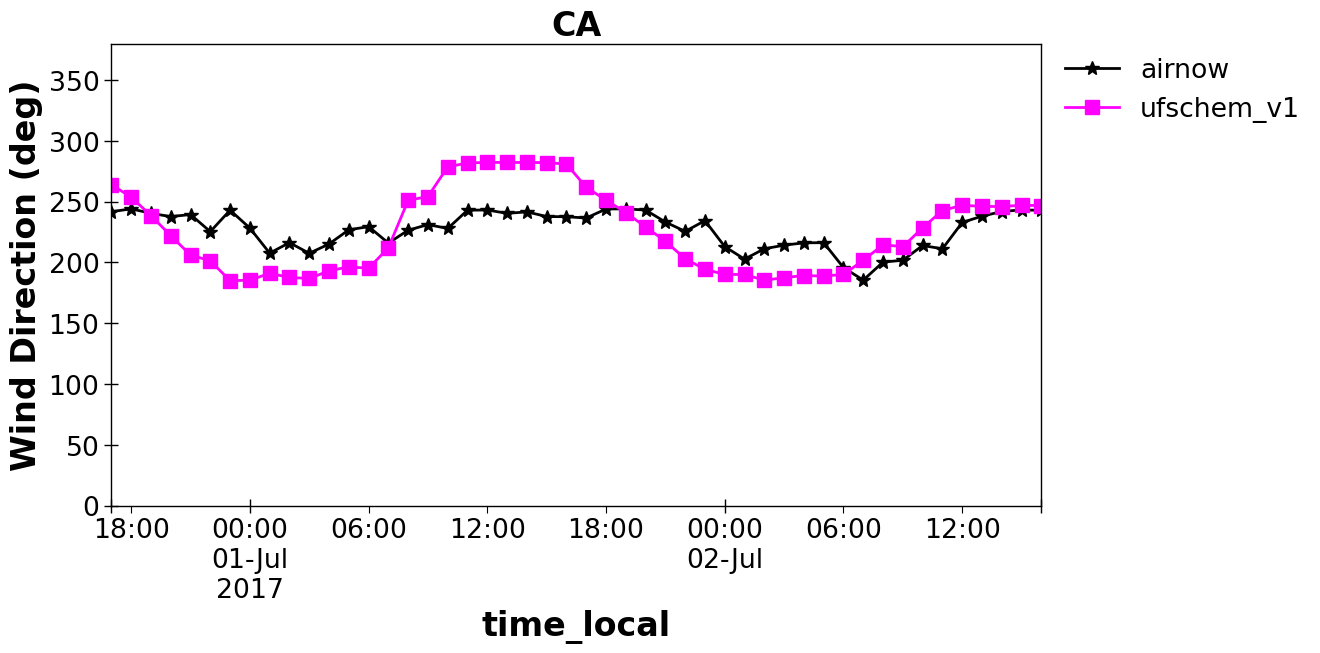

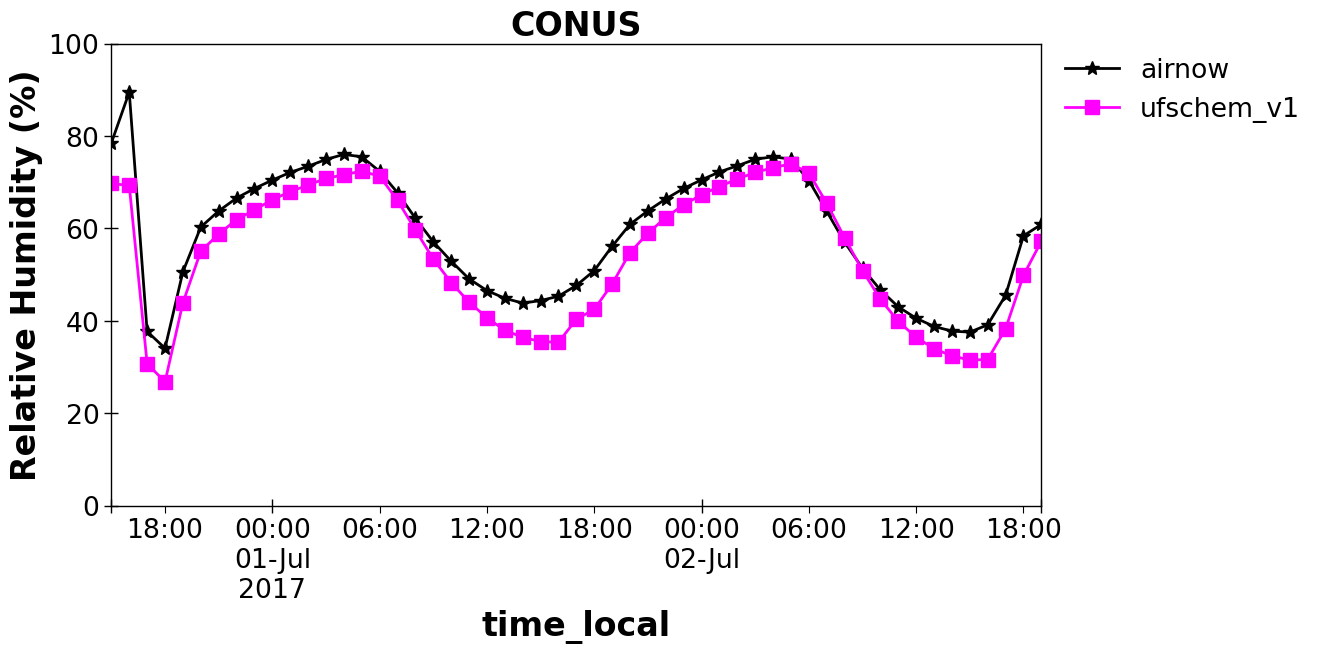

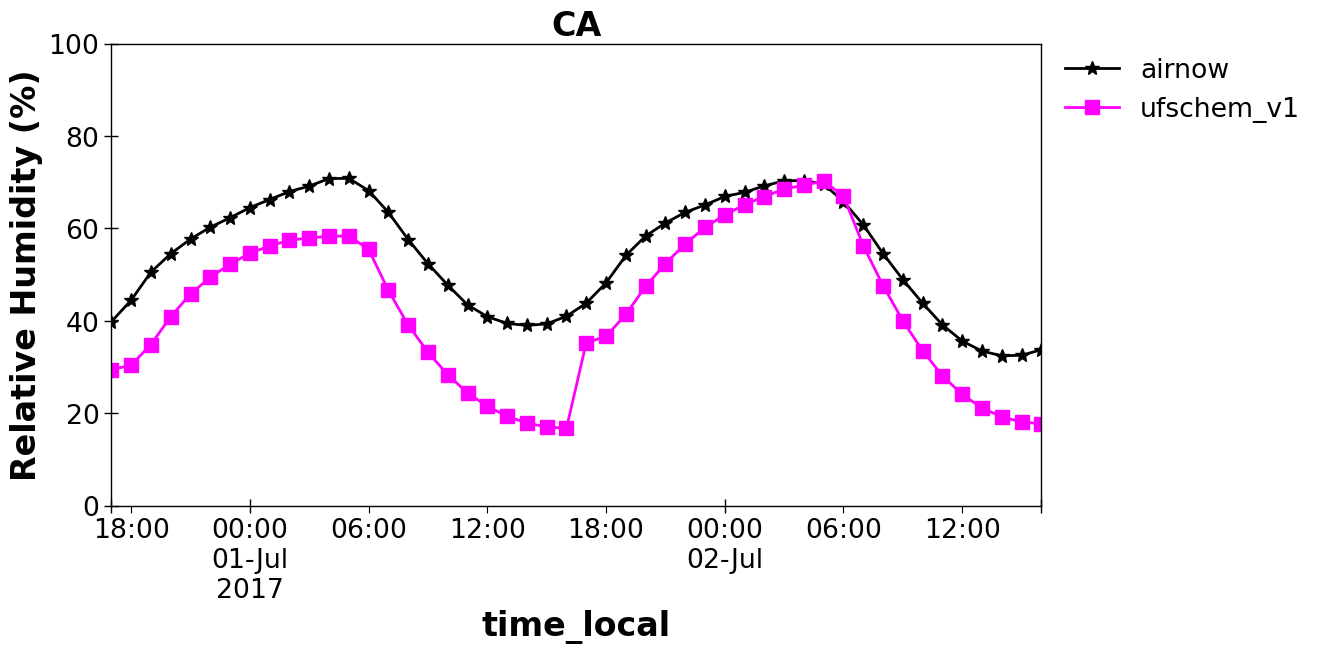

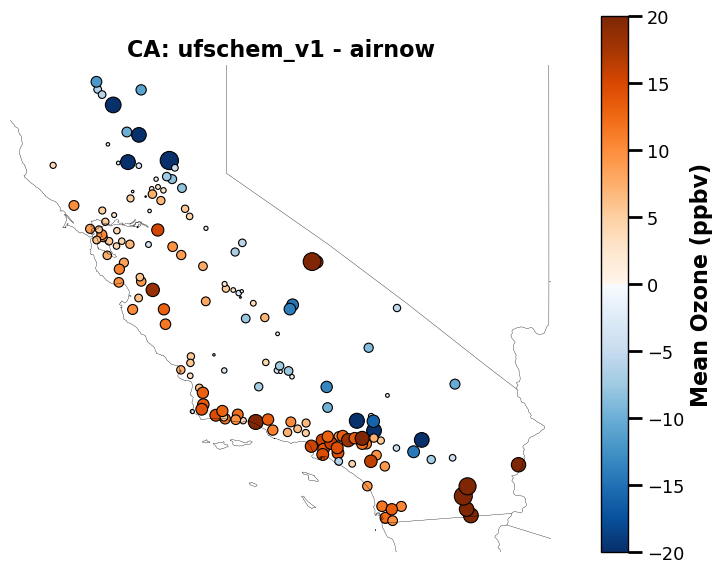

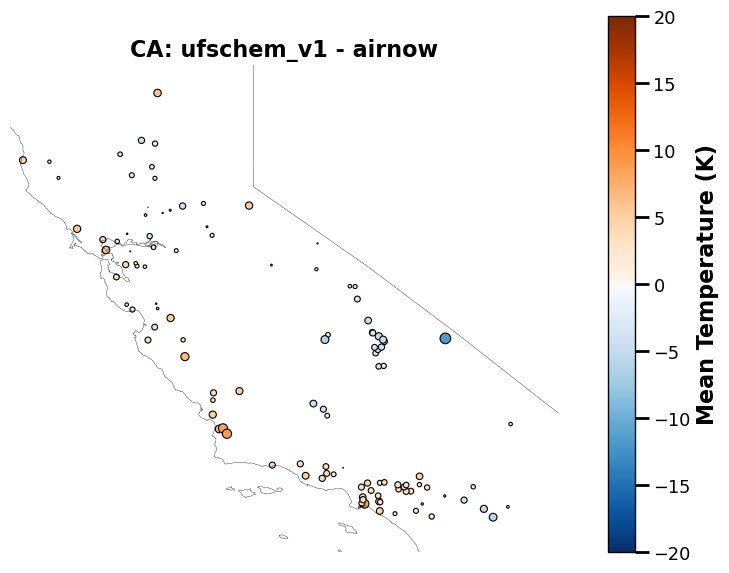

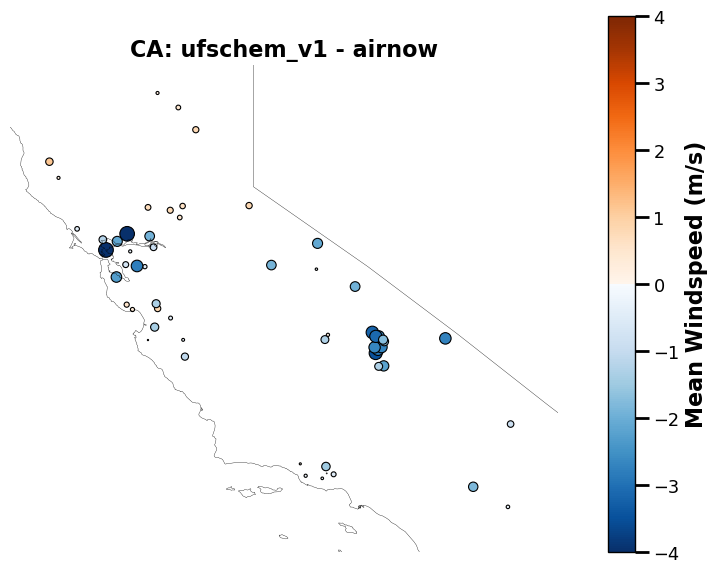

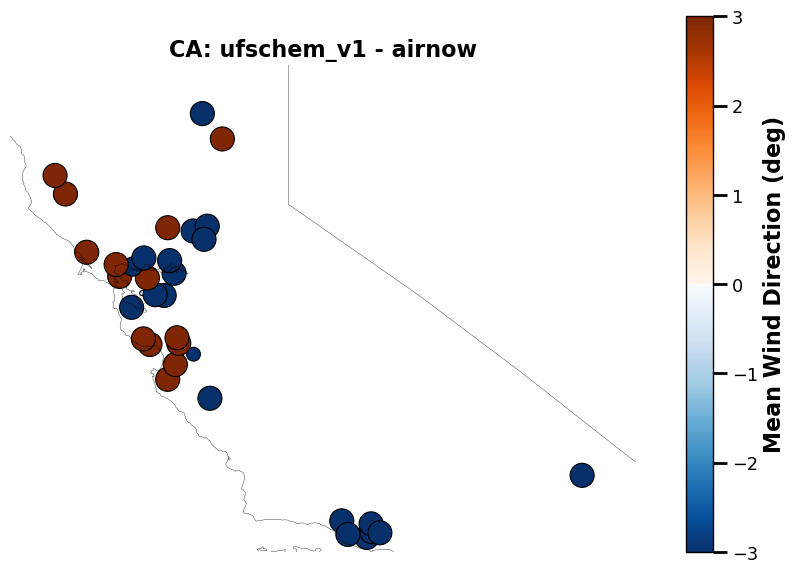

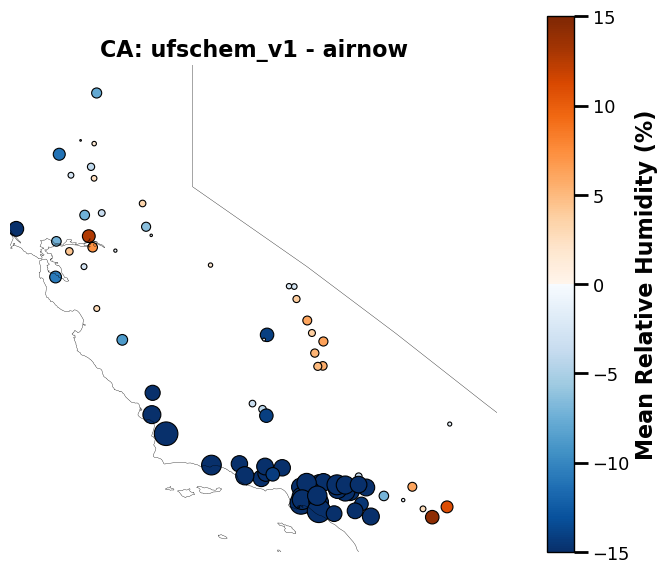

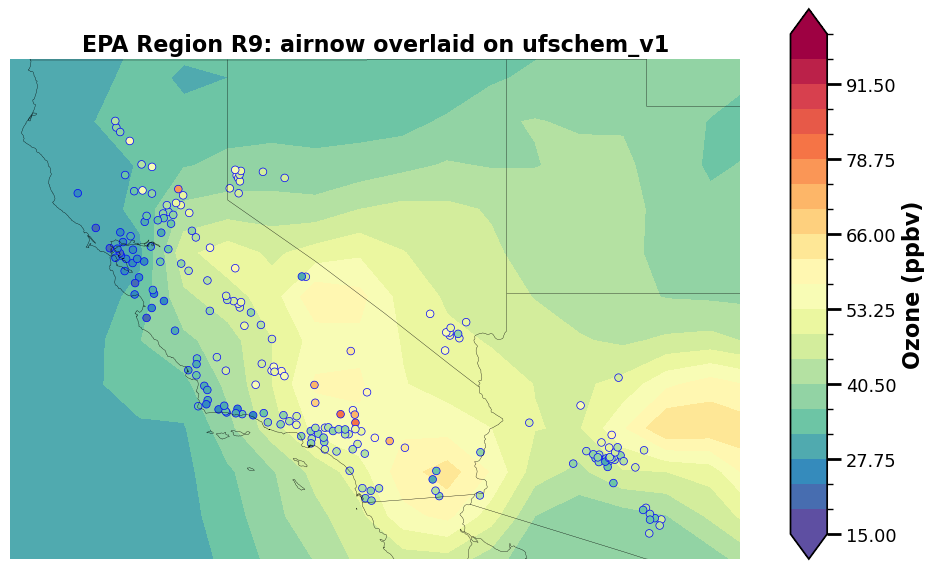

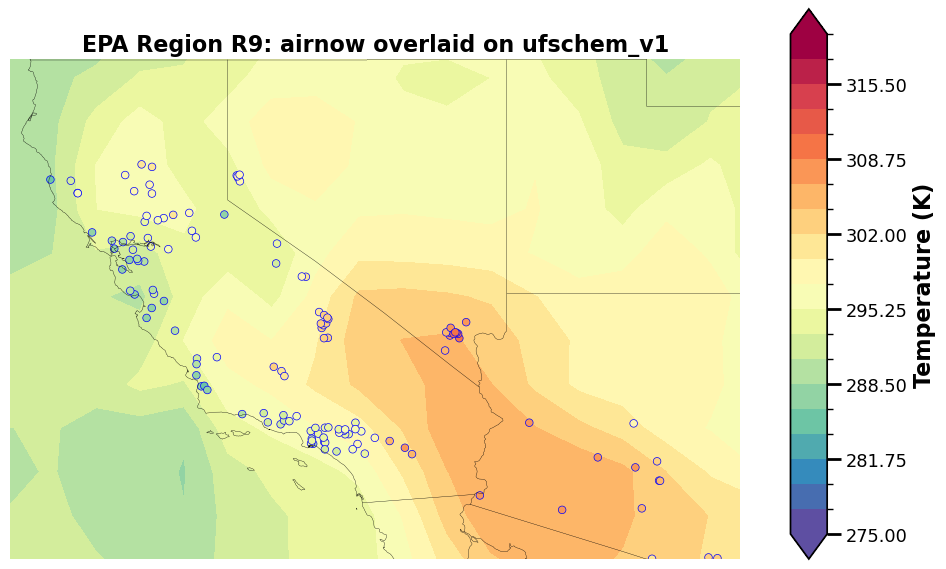

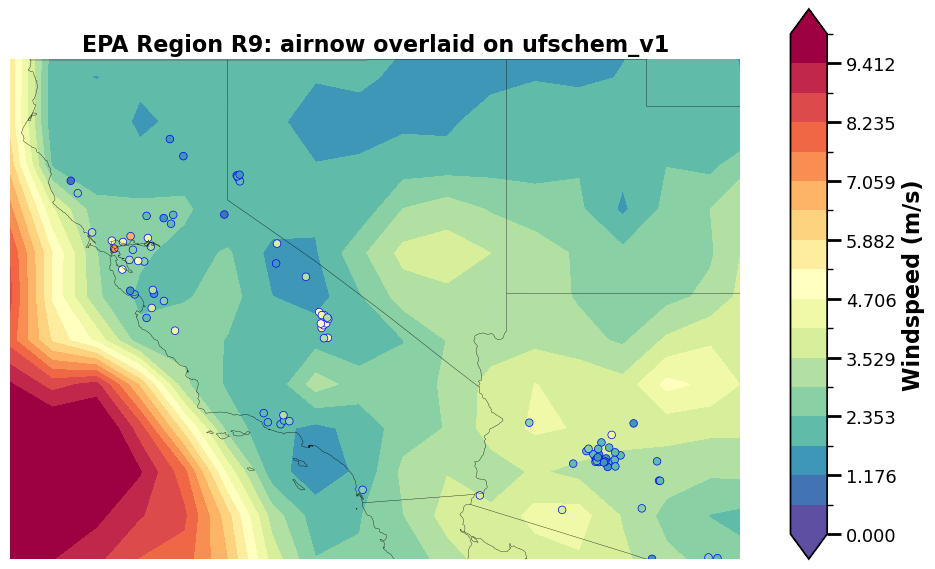

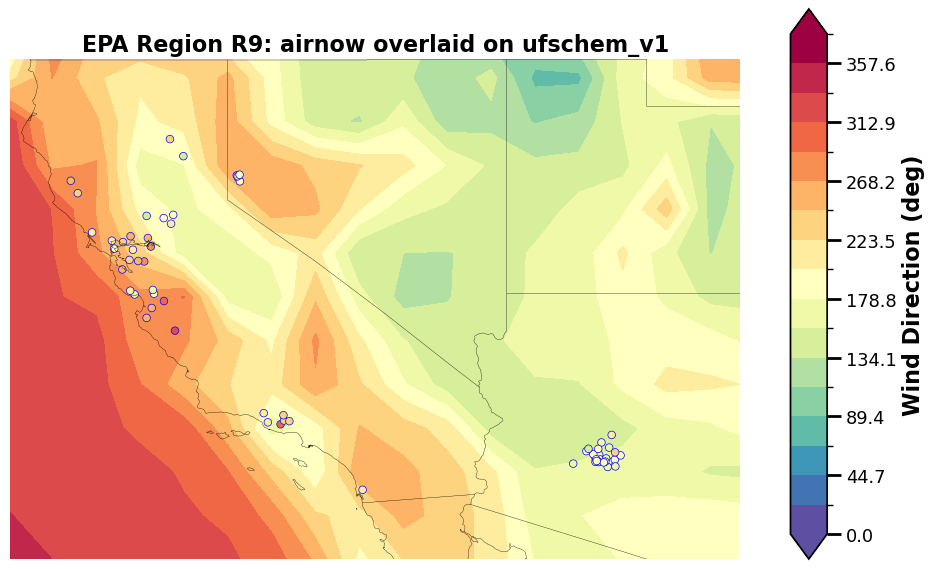

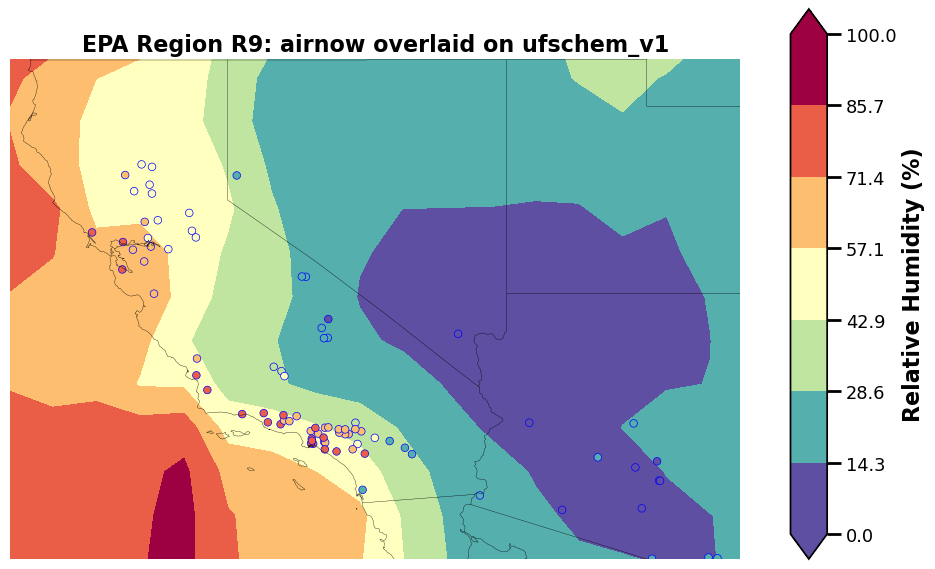

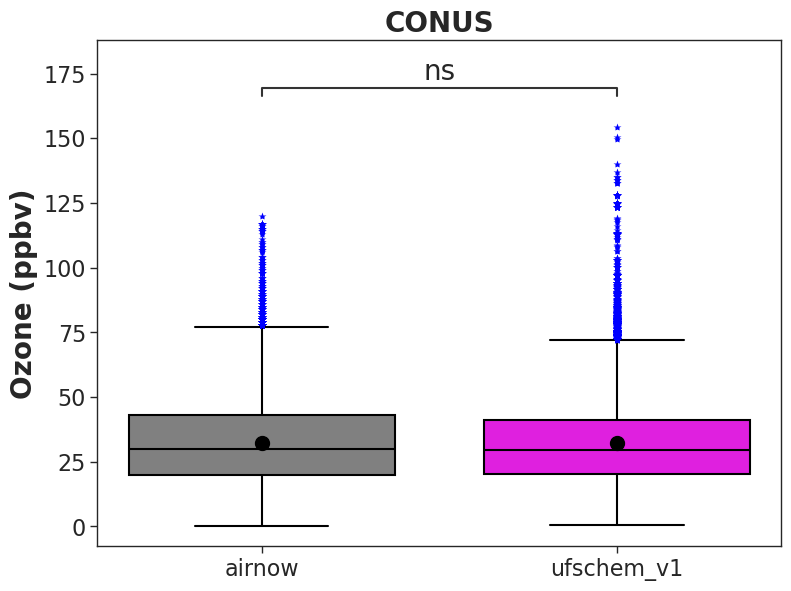

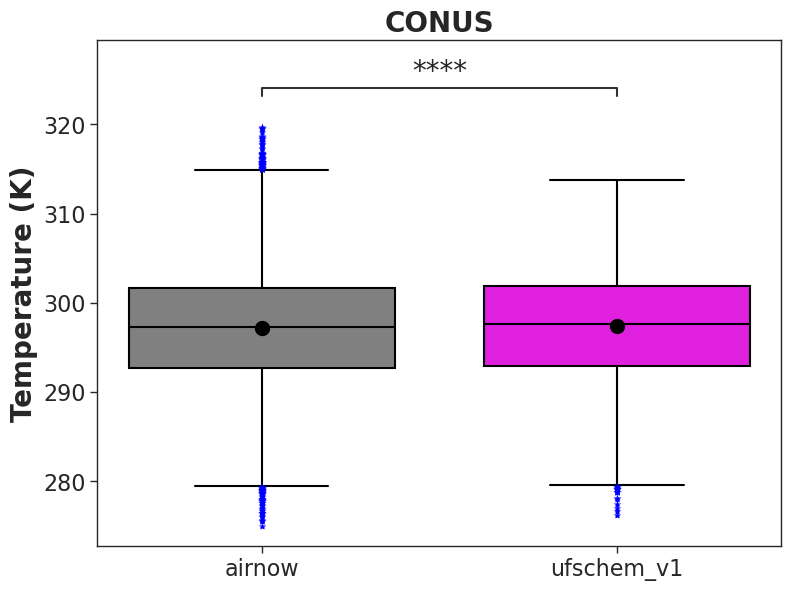

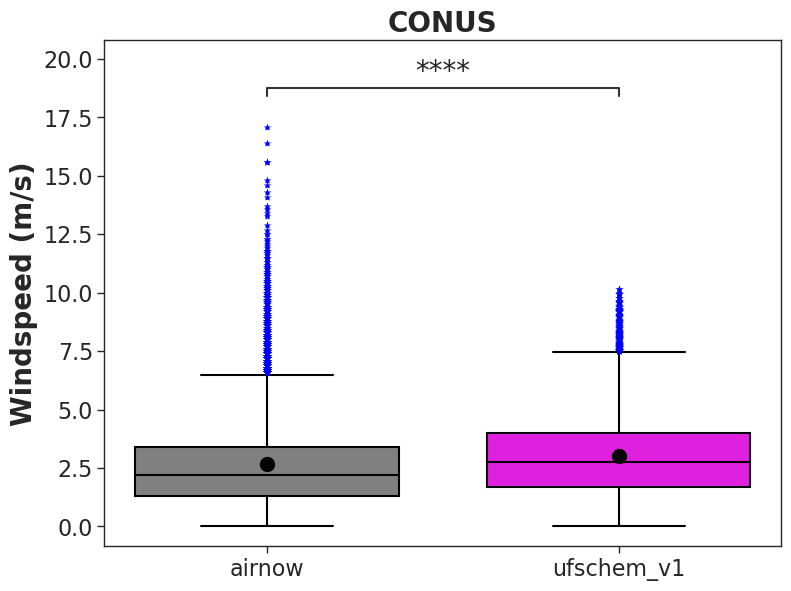

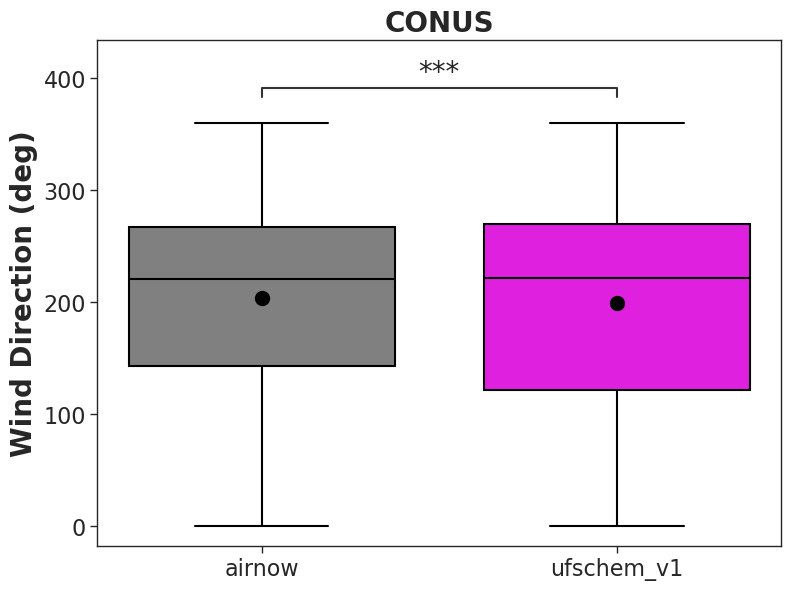

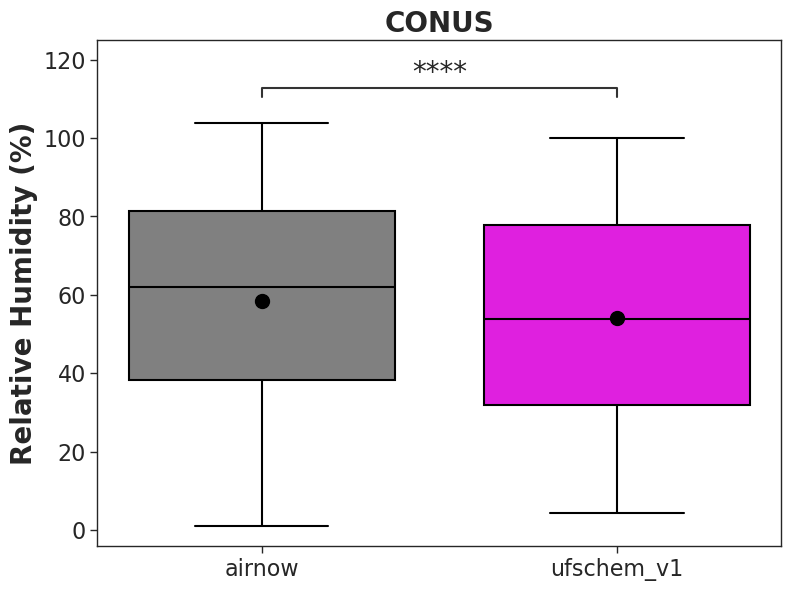

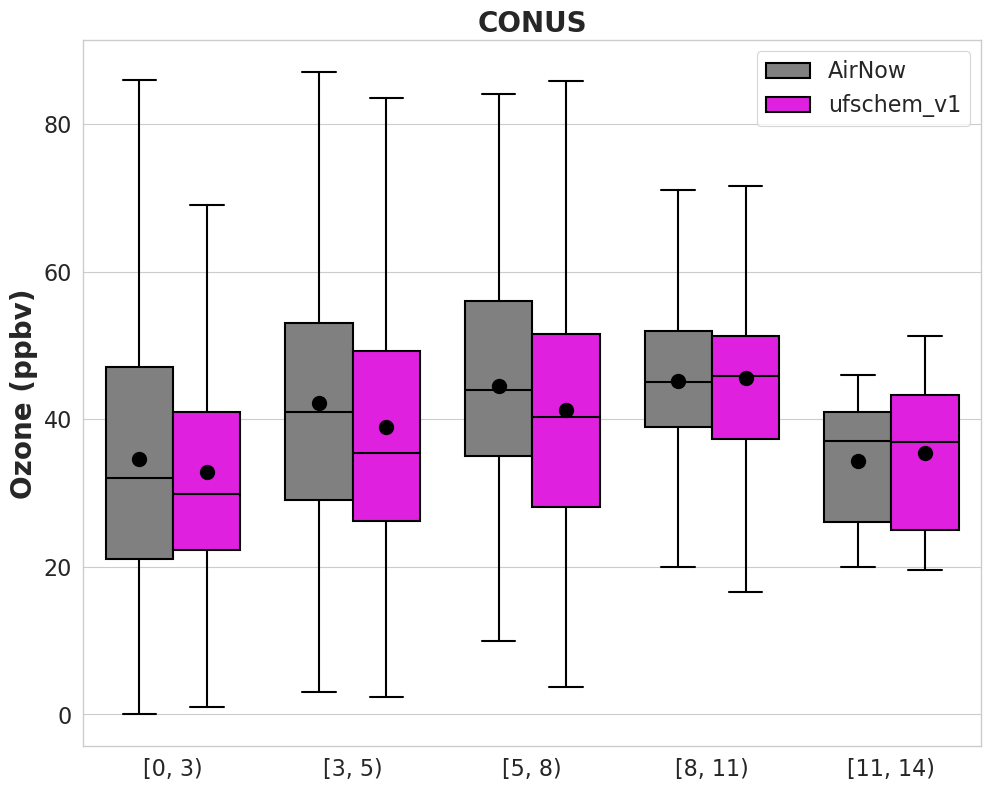

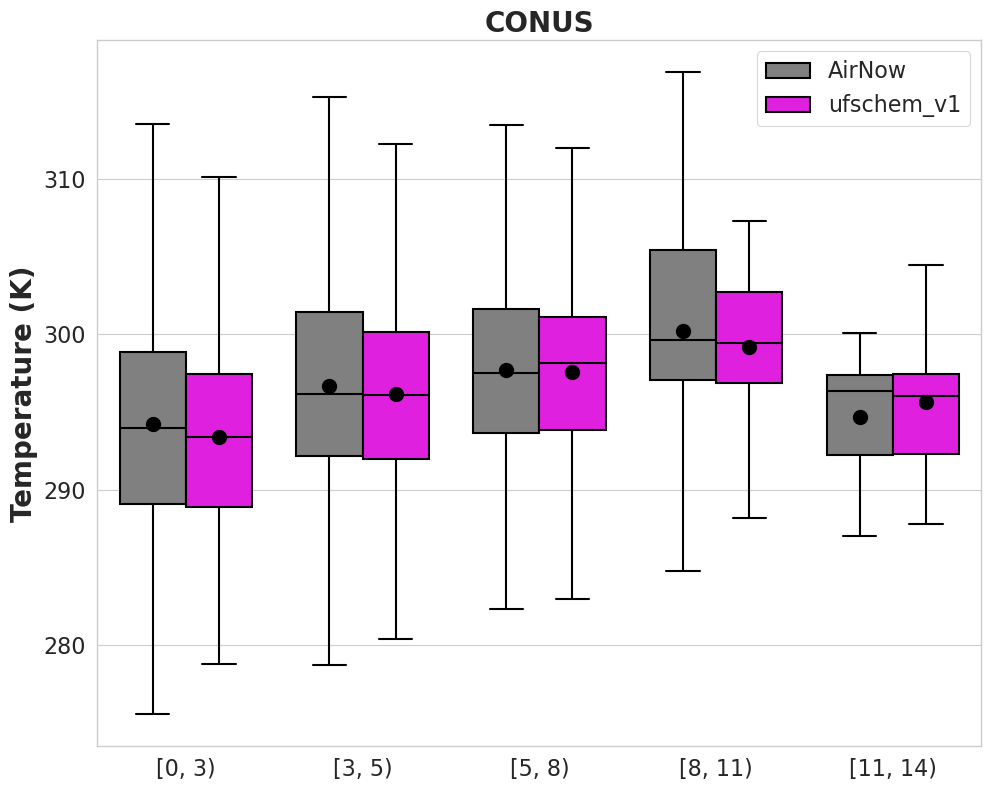

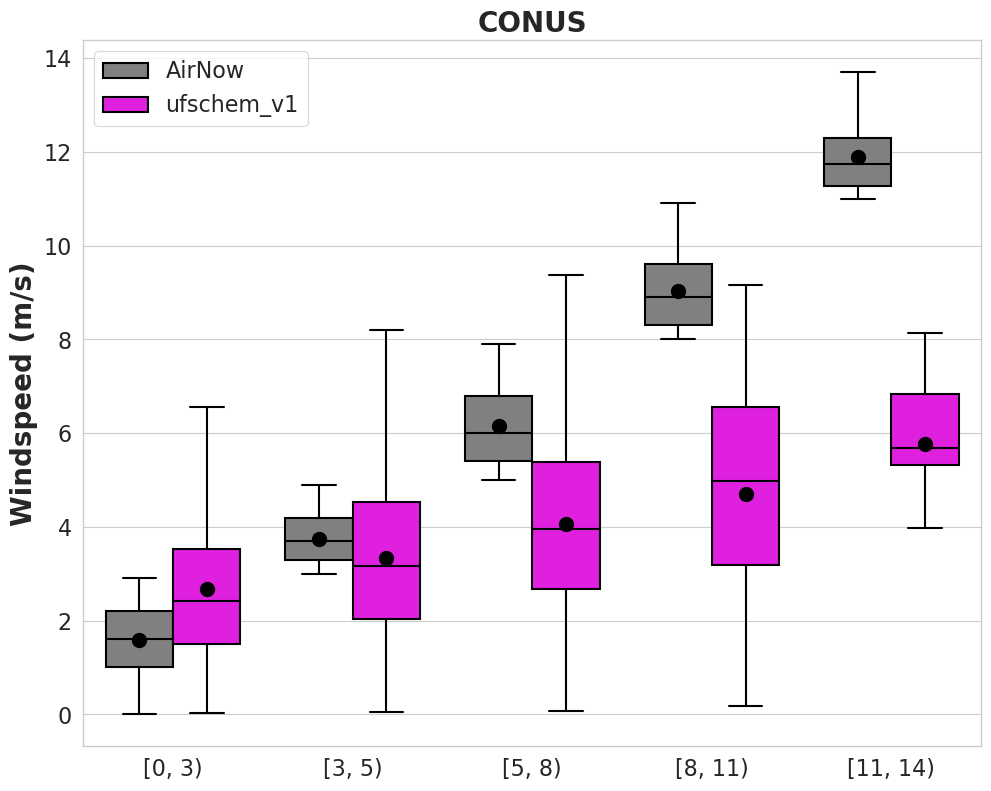

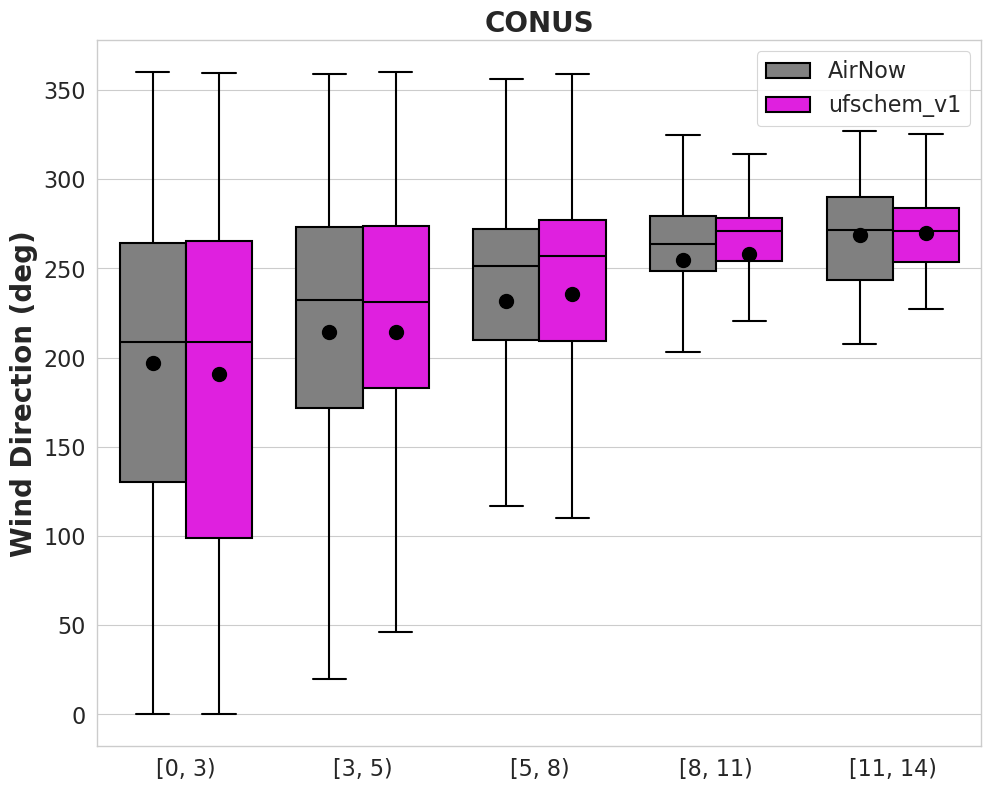

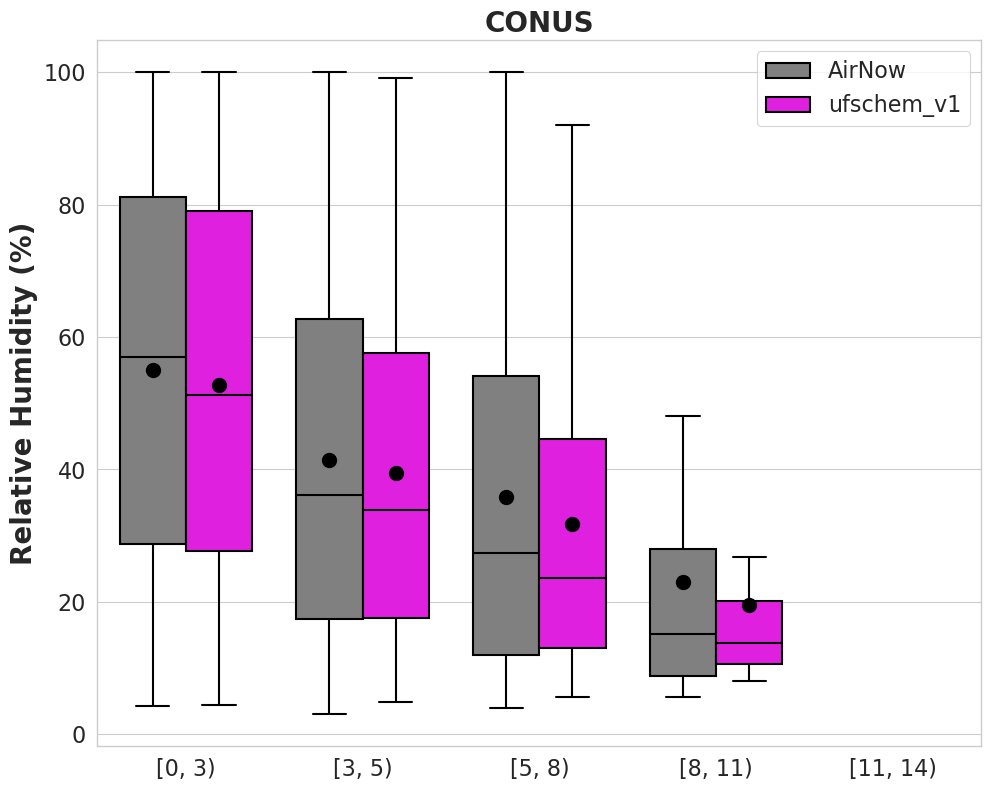

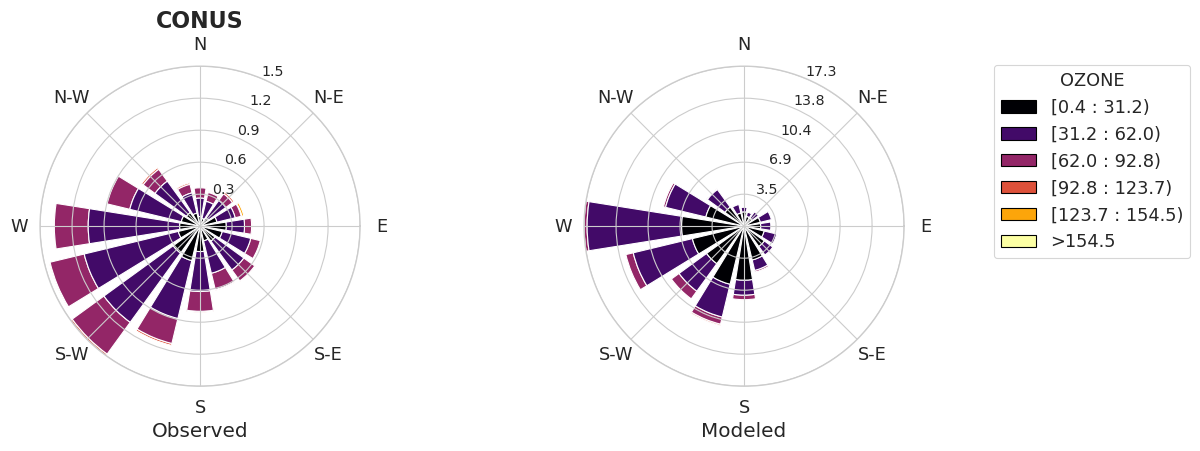

Saving rose plot to ./output/airnow_ufschem/plot_grp6.rose_plot.TEMP.2017-07-01_00.2017-07-03_00.all.CONUS...


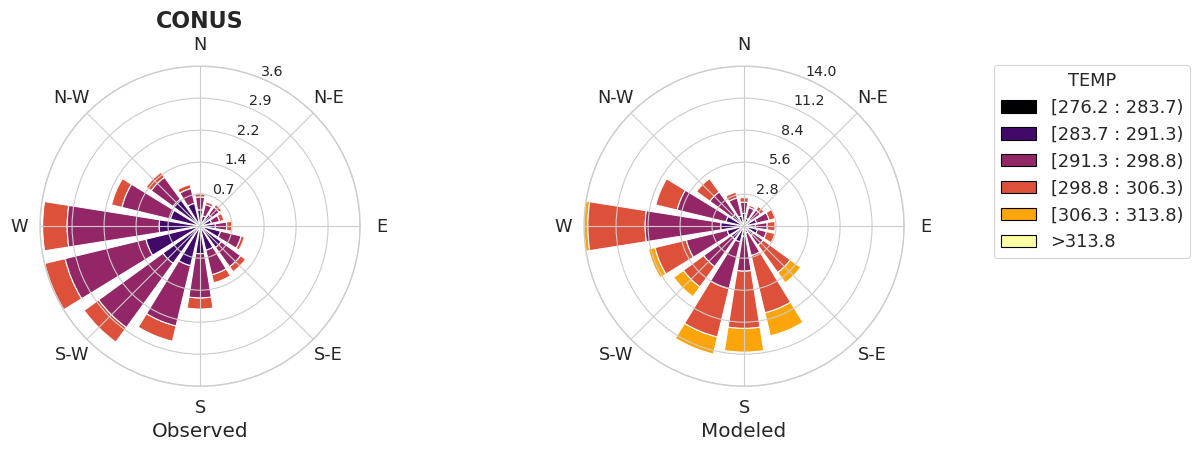

Saving rose plot to ./output/airnow_ufschem/plot_grp6.rose_plot.WS.2017-07-01_00.2017-07-03_00.all.CONUS...


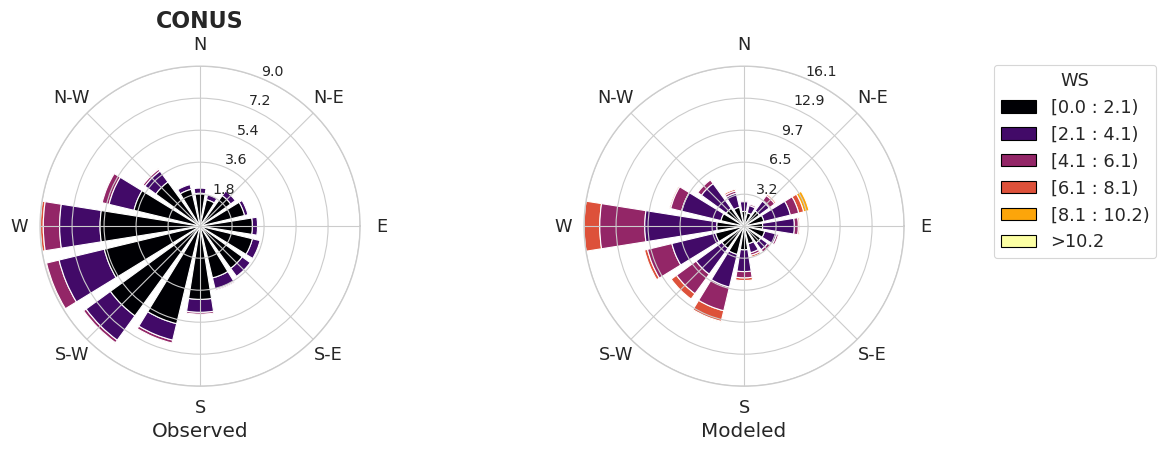

Saving rose plot to ./output/airnow_ufschem/plot_grp6.rose_plot.WD.2017-07-01_00.2017-07-03_00.all.CONUS...


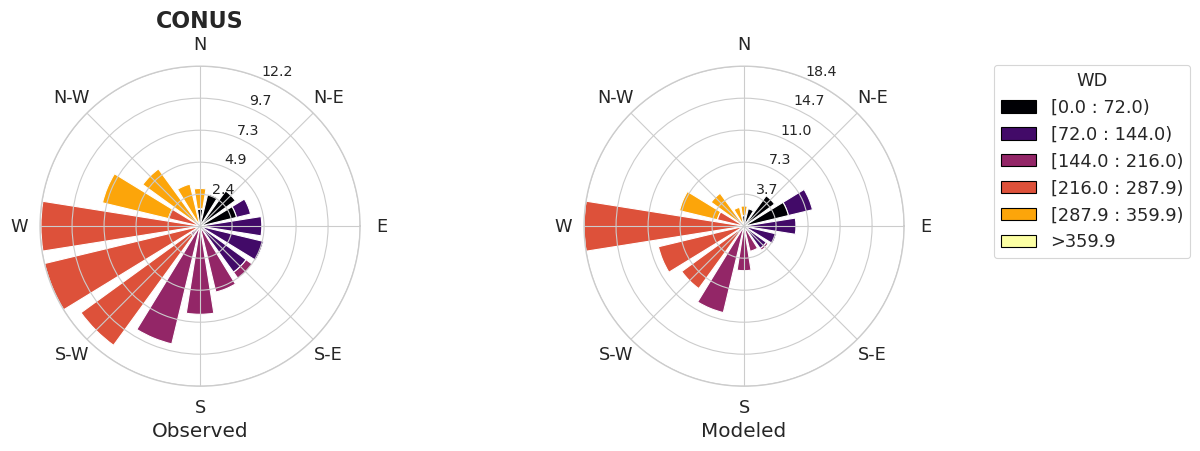

Saving rose plot to ./output/airnow_ufschem/plot_grp6.rose_plot.RHUM.2017-07-01_00.2017-07-03_00.all.CONUS...


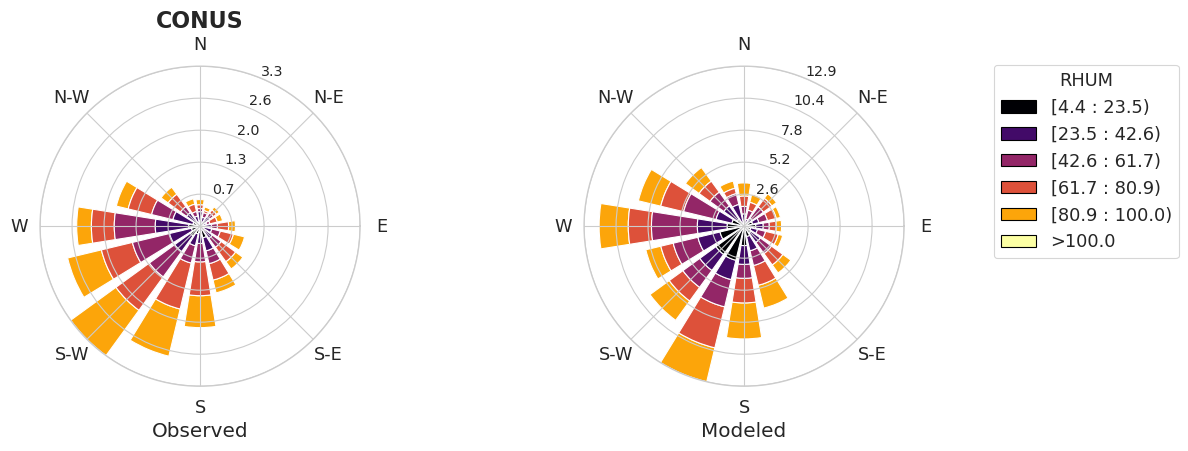

CPU times: user 1min 10s, sys: 1.93 s, total: 1min 12s
Wall time: 1min 12s


In [14]:
%%time

an.plotting()

CPU times: user 3.23 s, sys: 166 ms, total: 3.39 s
Wall time: 3.44 s


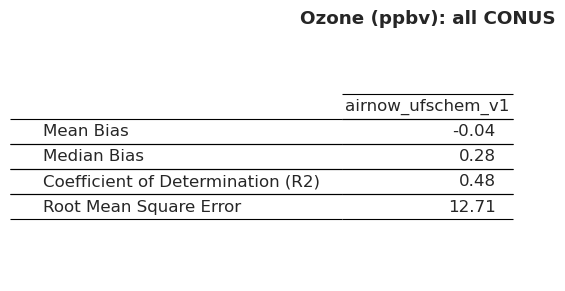

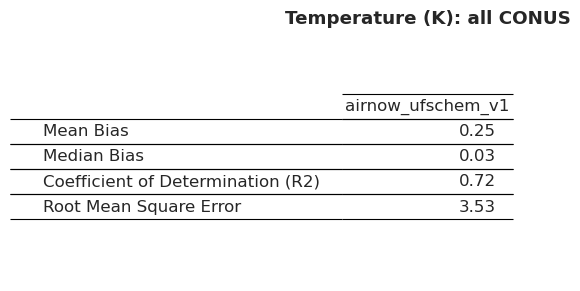

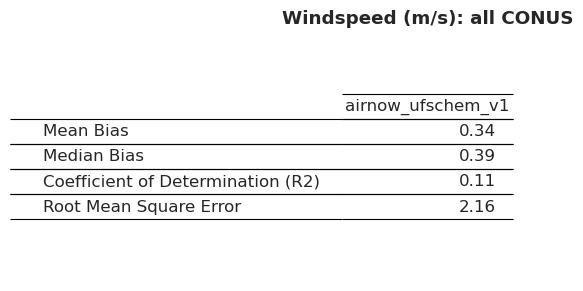

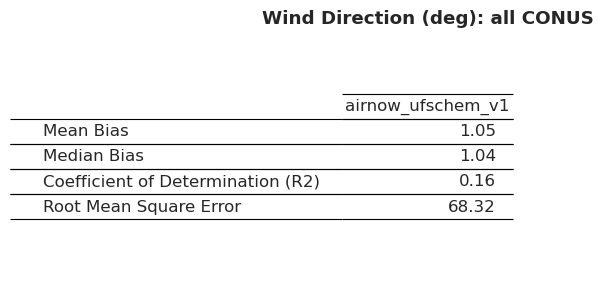

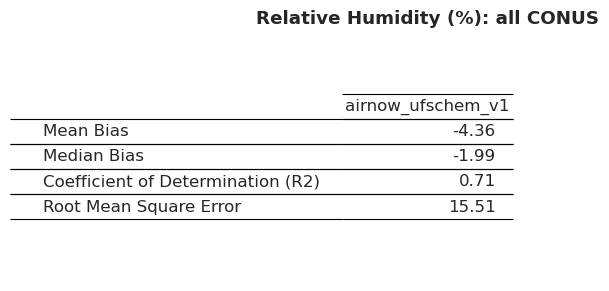

In [15]:
%%time

an.stats()

The stats routine has produced two files (one for each data variable).
This is one of them:
```{literalinclude} output/airnow_wrfchem/stats.OZONE.all.CONUS.2019-09-05_06.2019-09-06_06.csv
:caption:
```